In [1]:
import pandas as pd 
import numpy as np

In [2]:
df=pd.read_csv("weather_classification_data.csv")
df

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal,Snowy
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy


In [3]:
df.dtypes

Temperature             float64
Humidity                  int64
Wind Speed              float64
Precipitation (%)       float64
Cloud Cover              object
Atmospheric Pressure    float64
UV Index                  int64
Season                   object
Visibility (km)         float64
Location                 object
Weather Type             object
dtype: object

In [4]:
df.isna().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [5]:
df.shape

(13200, 11)

In [6]:
df.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
       'Visibility (km)', 'Location', 'Weather Type'],
      dtype='object')

In [7]:
df['Cloud Cover'].value_counts()

Cloud Cover
overcast         6090
partly cloudy    4560
clear            2139
cloudy            411
Name: count, dtype: int64

In [8]:
df['Season'].value_counts()

Season
Winter    5610
Spring    2598
Autumn    2500
Summer    2492
Name: count, dtype: int64

In [9]:
df['Location'].value_counts()

Location
inland      4816
mountain    4813
coastal     3571
Name: count, dtype: int64

In [10]:
df['Weather Type'].value_counts()

Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64

In [11]:
df=pd.get_dummies(df,columns=['Cloud Cover','Location'],dtype='int')
df

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Season,Visibility (km),Weather Type,Cloud Cover_clear,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Location_coastal,Location_inland,Location_mountain
0,14.0,73,9.5,82.0,1010.82,2,Winter,3.5,Rainy,0,0,0,1,0,1,0
1,39.0,96,8.5,71.0,1011.43,7,Spring,10.0,Cloudy,0,0,0,1,0,1,0
2,30.0,64,7.0,16.0,1018.72,5,Spring,5.5,Sunny,1,0,0,0,0,0,1
3,38.0,83,1.5,82.0,1026.25,7,Spring,1.0,Sunny,1,0,0,0,1,0,0
4,27.0,74,17.0,66.0,990.67,1,Winter,2.5,Rainy,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,1003.15,1,Summer,1.0,Rainy,0,0,1,0,0,0,1
13196,-1.0,76,3.5,23.0,1067.23,1,Winter,6.0,Snowy,0,1,0,0,1,0,0
13197,30.0,77,5.5,28.0,1012.69,3,Autumn,9.0,Cloudy,0,0,1,0,1,0,0
13198,3.0,76,10.0,94.0,984.27,0,Winter,2.0,Snowy,0,0,1,0,0,1,0


In [12]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
df['Season']=lb.fit_transform(df['Season'])
df['Weather Type']=lb.fit_transform(df['Weather Type'])

In [13]:
df

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Season,Visibility (km),Weather Type,Cloud Cover_clear,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Location_coastal,Location_inland,Location_mountain
0,14.0,73,9.5,82.0,1010.82,2,3,3.5,1,0,0,0,1,0,1,0
1,39.0,96,8.5,71.0,1011.43,7,1,10.0,0,0,0,0,1,0,1,0
2,30.0,64,7.0,16.0,1018.72,5,1,5.5,3,1,0,0,0,0,0,1
3,38.0,83,1.5,82.0,1026.25,7,1,1.0,3,1,0,0,0,1,0,0
4,27.0,74,17.0,66.0,990.67,1,3,2.5,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,1003.15,1,2,1.0,1,0,0,1,0,0,0,1
13196,-1.0,76,3.5,23.0,1067.23,1,3,6.0,2,0,1,0,0,1,0,0
13197,30.0,77,5.5,28.0,1012.69,3,0,9.0,0,0,0,1,0,1,0,0
13198,3.0,76,10.0,94.0,984.27,0,3,2.0,2,0,0,1,0,0,1,0


In [14]:
df['Season'].value_counts()

Season
3    5610
1    2598
0    2500
2    2492
Name: count, dtype: int64

In [15]:
df['Weather Type'].value_counts()

Weather Type
1    3300
0    3300
3    3300
2    3300
Name: count, dtype: int64

In [16]:
df.dtypes

Temperature                  float64
Humidity                       int64
Wind Speed                   float64
Precipitation (%)            float64
Atmospheric Pressure         float64
UV Index                       int64
Season                         int64
Visibility (km)              float64
Weather Type                   int64
Cloud Cover_clear              int64
Cloud Cover_cloudy             int64
Cloud Cover_overcast           int64
Cloud Cover_partly cloudy      int64
Location_coastal               int64
Location_inland                int64
Location_mountain              int64
dtype: object

In [17]:
df.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Atmospheric Pressure', 'UV Index', 'Season', 'Visibility (km)',
       'Weather Type', 'Cloud Cover_clear', 'Cloud Cover_cloudy',
       'Cloud Cover_overcast', 'Cloud Cover_partly cloudy', 'Location_coastal',
       'Location_inland', 'Location_mountain'],
      dtype='object')

In [18]:
#rearranging the columns
df=df[['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Atmospheric Pressure', 'UV Index','Visibility (km)', 'Season', 'Cloud Cover_clear', 'Cloud Cover_cloudy',
       'Cloud Cover_overcast', 'Cloud Cover_partly cloudy', 'Location_coastal',
       'Location_inland', 'Location_mountain','Weather Type']]
df.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Atmospheric Pressure', 'UV Index', 'Visibility (km)', 'Season',
       'Cloud Cover_clear', 'Cloud Cover_cloudy', 'Cloud Cover_overcast',
       'Cloud Cover_partly cloudy', 'Location_coastal', 'Location_inland',
       'Location_mountain', 'Weather Type'],
      dtype='object')

In [19]:
#Labelling the data
x=df.drop(['Weather Type'],axis=1)
y=df['Weather Type']

In [20]:
#train,test,split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [21]:
x_train.shape

(10560, 15)

In [22]:
x_test.shape

(2640, 15)

In [23]:
y_train.shape

(10560,)

In [25]:
y_test.shape

(2640,)

In [26]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [27]:
x_train

array([[ 0.72798445, -0.129706  , -0.5536792 , ..., -0.61529674,
         1.32531523, -0.75422841],
       [-0.2483393 ,  1.35248791,  0.17067625, ..., -0.61529674,
        -0.75453747,  1.3258583 ],
       [ 0.49826122, -0.52495771, -0.48124366, ..., -0.61529674,
         1.32531523, -0.75422841],
       ...,
       [ 0.84284607, -0.82139649, -0.40880811, ...,  1.62523208,
        -0.75453747, -0.75422841],
       [-0.59292416,  0.21613924,  0.02580516, ..., -0.61529674,
        -0.75453747,  1.3258583 ],
       [-0.47806254,  1.30308144, -0.62611475, ...,  1.62523208,
        -0.75453747, -0.75422841]])

In [28]:
x_test

array([[ 0.21110717, -1.51308699, -0.77098584, ..., -0.61529674,
         1.32531523, -0.75422841],
       [ 2.45090872,  1.25367498,  0.67772508, ..., -0.61529674,
         1.32531523, -0.75422841],
       [ 1.18743092, -0.87080296, -1.13316357, ..., -0.61529674,
        -0.75453747,  1.3258583 ],
       ...,
       [-1.33952467,  1.25367498, -0.84342139, ..., -0.61529674,
        -0.75453747,  1.3258583 ],
       [-1.28209387,  1.45130083, -0.26393702, ..., -0.61529674,
        -0.75453747,  1.3258583 ],
       [ 0.15367636,  0.16673278, -0.33637257, ..., -0.61529674,
        -0.75453747,  1.3258583 ]])

In [29]:
#Model training and testing
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [30]:
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

In [31]:
y_pred

array([3, 3, 3, ..., 2, 2, 0])

In [32]:
from sklearn.metrics import accuracy_score,confusion_matrix
lr_acc=accuracy_score(y_test,y_pred)
print(lr_acc)

0.8761363636363636


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

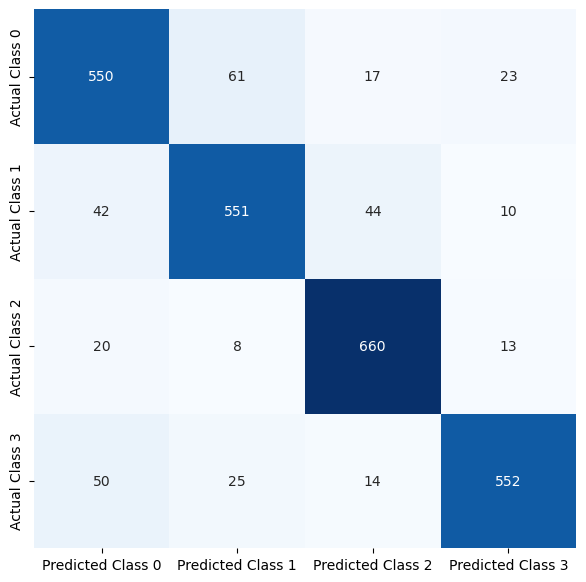

In [35]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(7,7))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,
            xticklabels=['Predicted Class 0','Predicted Class 1','Predicted Class 2','Predicted Class 3'],
            yticklabels=['Actual Class 0','Actual Class 1','Actual Class 2','Actual Class 3'])  #annot- used for display values inside graph #fmt- used for showing int value
plt.show()

In [36]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()

In [37]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

In [39]:
dtc_pred=dtc.predict(x_test)
dtc_pred

array([3, 3, 3, ..., 2, 2, 0])

In [40]:
dtc_acc=accuracy_score(y_test,dtc_pred)
print(dtc_acc)

0.9068181818181819


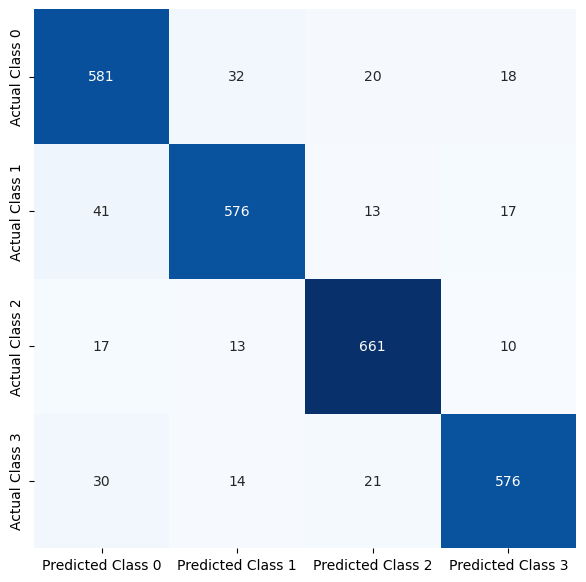

In [42]:
cm=confusion_matrix(y_test,dtc_pred)
plt.figure(figsize=(7,7))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,
            xticklabels=['Predicted Class 0','Predicted Class 1','Predicted Class 2','Predicted Class 3'],
            yticklabels=['Actual Class 0','Actual Class 1','Actual Class 2','Actual Class 3'])  #annot- used for display values inside graph #fmt- used for showing int value
plt.show()

In [43]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier()

In [44]:
rfc.fit(x_train,y_train)

RandomForestClassifier()

In [45]:
rfc_pred=rfc.predict(x_test)
rfc_pred

array([3, 3, 3, ..., 2, 2, 0])

In [46]:
rfc_acc=accuracy_score(y_test,rfc_pred)
print(rfc_acc)

0.9136363636363637


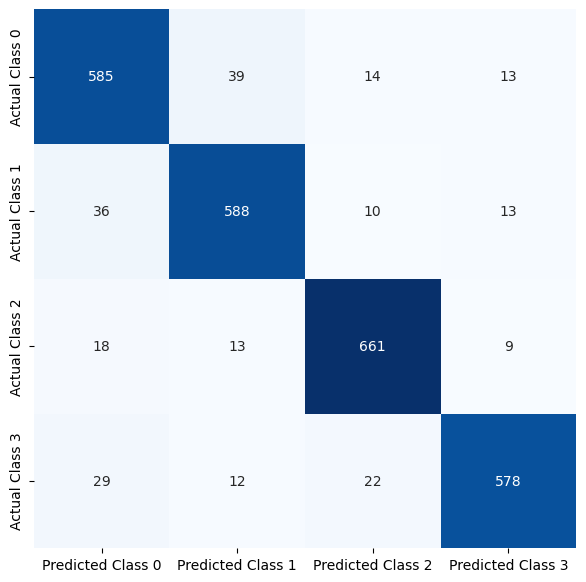

In [47]:
cm=confusion_matrix(y_test,rfc_pred)
plt.figure(figsize=(7,7))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,
            xticklabels=['Predicted Class 0','Predicted Class 1','Predicted Class 2','Predicted Class 3'],
            yticklabels=['Actual Class 0','Actual Class 1','Actual Class 2','Actual Class 3'])  #annot- used for display values inside graph #fmt- used for showing int value
plt.show()

In [48]:
from sklearn.svm import SVC
svc=SVC()

In [49]:
svc.fit(x_train,y_train)

SVC()

In [50]:
svc_pred=svc.predict(x_test)
svc_pred

array([3, 3, 3, ..., 2, 2, 0])

In [51]:
svc_acc=accuracy_score(y_test,svc_pred)
print(svc_acc)

0.9018939393939394


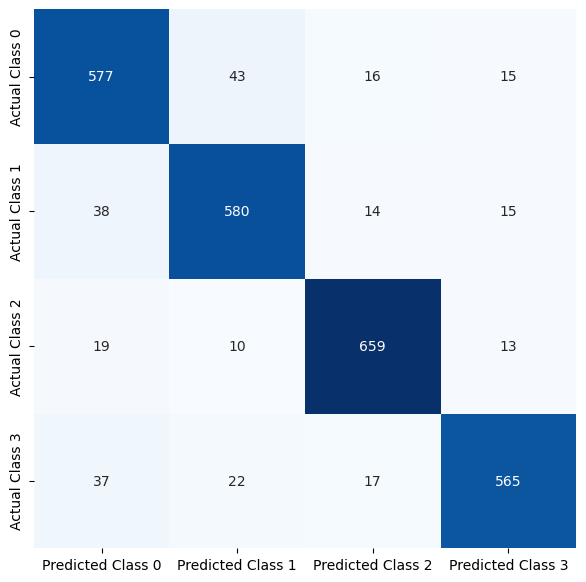

In [52]:
cm=confusion_matrix(y_test,svc_pred)
plt.figure(figsize=(7,7))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,
            xticklabels=['Predicted Class 0','Predicted Class 1','Predicted Class 2','Predicted Class 3'],
            yticklabels=['Actual Class 0','Actual Class 1','Actual Class 2','Actual Class 3'])  #annot- used for display values inside graph #fmt- used for showing int value
plt.show()

In [53]:
import pickle
with open('rfc-weather.pkl','wb') as file:
    pickle.dump(rfc,file)

In [55]:
with open('scaler-weather.pkl','wb') as file:
    pickle.dump(sc,file)

In [56]:
with open('rfc-weather.pkl','rb') as file:
    model=pickle.load(file)
    print(model)

RandomForestClassifier()


In [57]:
with open('scaler-weather.pkl','rb') as file:
    scaler=pickle.load(file)
    print(scaler)

StandardScaler()


In [58]:
def predict(values):
    values=scaler.transform([values])
    result=model.predict(values)
    if result==[0]:
        print('Cloudy')
    elif result==[1]:
        print('Rainy')
    elif result==[2]:
        print('Snowy')
    else:
        print('Sunny')

In [62]:
df.iloc[466]

Temperature                    40.00
Humidity                       96.00
Wind Speed                      1.00
Precipitation (%)              88.00
Atmospheric Pressure         1021.63
UV Index                        0.00
Visibility (km)                 7.50
Season                          2.00
Cloud Cover_clear               1.00
Cloud Cover_cloudy              0.00
Cloud Cover_overcast            0.00
Cloud Cover_partly cloudy       0.00
Location_coastal                0.00
Location_inland                 0.00
Location_mountain               1.00
Weather Type                    3.00
Name: 466, dtype: float64

In [63]:
predict(x.iloc[466])

Sunny


C:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
